# Analysis of Climate Change, Soil Moisture, and Vegetation Health at the Lamont Sanctuary Forest

## Kira Wiesinger, ktw2128

### Summary
This project is an analysis of long-term climate trends, Normalized Difference Vegetation Index (NDVI) as an indicator of vegetation health, and soil moisture dynamics at the Lamont Sanctuary Forest, Palisades NY, using remote sensing and ground-based measurements.

Project ideation and dataset choices were supported by Dr. Yushu Xia.

### Scientific Question
How do soil moisture, temperature, and precipitation influence the health 
of the Lamont Sanctuary Forest over 2000-2024, and how do forest characteristics vary across seasons?

### Null hypotheses:

There is ... 
- no significant relationship between air temperature and NDVI (Null Hyp 1)
- no significant relationship between soil moisture and NDVI (Null Hyp 2)
- no significant relationship between precipitation and NDVI (Null Hyp 3)
- no significant relationship between soil moisture and canopy height (Null hyp 4)
- no significant trend in temperature or precipitation (Null Hyp 5)
 
... at the Lamont Sanctuary Forest over 2000–2024. 

GLDAS-modeled soil moisture accurately represents fine-scale soil moisture variability at the Lamont Sanctuary Forest. (Null Hyp 6)

Note: Hypotheses 4 and 6 were not evaluated over the entire duration of the study period.


### Alternative hypotheses:

There are positive associations between ...
- air temperature and NDVI (Alt Hyp 1)
- soil moisture and NDVI (Alt Hyp 2)
- precipitation and NDVI (Alt Hyp 3)
  
... at the Lamont Sanctuary Forest over 2000–2024.

Grid points with taller canopy have significantly different soil moisture than points with shorter canopy (Alt Hyp 4)

Significant increase in temperature while no significant change in precipitation. (Alt Hyp 5)

GLDAS-modeled soil moisture does not accurately capture fine-scale soil moisture variability at the Lamont Sanctuary Forest due to its coarse 25km resolution. (Alt Hyp 6)

### Datasets

All remote sensing datasets were accessed and extracted using Google Earth Engine (GEE) and were were spatially filtered in GEE to the Lamont Sanctuary Forest boundary polygon. Ground-based measurements were collected by the Lamont-Doherty Earth Observatory (LDEO) Xia Soil Systems Lab.

* **Daymet V4** (`NASA/ORNL/DAYMET_V4`): Daily surface weather summaries including 
  maximum temperature, minimum temperature, and precipitation at 1km resolution (2000-2024). 
  Produced by NASA/ORNL.

* **Global Land Data Assimilation System Version 2 (GLDAS-2.1)** (`NASA/GLDAS/V021/NOAH/G025/T3H`): 
  3-hourly modeled soil moisture (0-10cm, 10-40cm), air temperature, precipitation, and 
  evapotranspiration at 25km resolution (2000-2025). Produced by NASA/GSFC.

* **Landsat 7/8/9 Collection 2 Surface Reflectance** (`LANDSAT/LE07/C02/T1_L2`, 
  `LANDSAT/LC08/C02/T1_L2`, `LANDSAT/LC09/C02/T1_L2`): NDVI 
  derived from surface reflectance at 30m resolution (2000-2024). Produced by USGS.

* **Meta/World Resources Institute Global Canopy Height** 
  (`projects/sat-io/open-datasets/facebook/meta-canopy-height`): 
  1m resolution canopy height map derived from satellite imagery using AI, 
  representing a snapshot of ~2018-2020. Developed by Meta and WRI.

* **Lamont Sanctuary Forest (LSF) boundary** (`projects/landscape-analysis-ktw2128/assets/LSF`): 
  Vector polygon defining the ~1.5 hectare study site boundary, uploaded as a 
  Google Earth Engine asset and used to spatially filter all remote sensing 
  datasets to the LSF study area. LSF is a Columbia University campus experimental site for research and education on ecological restoration, carbon cycling, and climate change mitigation in temperate hardwood systems.

* **LDEO Xia Soil Systems Lab Time Domain Reflectometry (TDR) grid**: 
  Ground-based soil moisture measurements (% VWC) at 121 grid points across 
  the ~1.5 hectare LSF study site, collected in August 2024 and June-July 2025.

* **LDEO Xia Soil Systems Lab continuous sensor**: 15-minute volumetric water 
  content (VWC) measurements at a single point within the LSF study site 
  (October 2024 - May 2025).

The Google Earth Engine script is available at https://code.earthengine.google.com/f14a4e45780f76a3e911c1b715b9e9d4
(Note: I originally extracted Sentinel-2 but ultimately excluded it from the project because I found Landsat to be more useful, thus making Sentinel-2 redundant.)

## Hypothesis evaluation

For the first three hypotheses, Pearson correlation coefficients were calculated to evaluate the linear relationships between NDVI and three climate drivers: air temperature, soil moisture, and precipitation. 

For the fourth hypothesis, the relationship between canopy structure and soil moisture was tested using two approaches. First, I ran a Pearson correlation between canopy height and mean volumetric water content across TDR grid points. Second, I ran an independent samples t-test comparing mean soil moisture between grid points with tall versus short canopy, split at the 
median canopy height.

For the fifth hypothesis, long-term trends in temperature and precipitation were assessed using linear regression on annual means derived from Daymet V4.

For the sixth hypothesis, the accuracy of GLDAS-modeled soil moisture was evaluated by comparing daily GLDAS 0-10cm soil moisture estimates against continuous ground-based sensor measurements 
during their overlapping period (October 2024 - May 2025) using Pearson correlation.

All statistical tests used a significance threshold of α=0.05.

## Python Libraries

In [1]:
import os
os.environ['PROJ_LIB'] = '/opt/sw/anaconda3/2023.09/share/proj'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import stats
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import rasterio
from rasterio.plot import show

## Load datasets in Pandas

In [2]:
df_daymet_raw = pd.read_csv('Daymet_LSF_Data.csv')
df_landsat_raw = pd.read_csv('Landsat_NDVI_LSF.csv')
df_gldas_raw = pd.read_csv('GLDAS_LSF_Data.csv')
df_grid_2025_raw = pd.read_csv('LSF_Soil_Moisture_Grid_2025_Summer.csv')
df_sensor_raw = pd.read_csv('LSF_Soil_Moisture_Sensor_Data.csv', usecols=[0, 1])
df_grid_2024_raw = pd.read_csv('LSF_Soil Moisture_Grid_2024_Summer.csv', header=None)
df_coords_raw = pd.read_csv('GPS_Grid-based-coordinates_2024_Fall.csv')

## Clean datasets

Set dataframes to datetime, drop NA and invalid values, do unit conversion where necessary, create monthly aggrefated dataframes for some variables, define seasons, and merge the grid data with coordinate data.

In [3]:
# -----------------------------------------------
# DAYMET: dates, sort, drop missing
# -----------------------------------------------
df_daymet = df_daymet_raw.copy()
df_daymet['date'] = pd.to_datetime(df_daymet['date'])
df_daymet = df_daymet.sort_values('date').reset_index(drop=True)
df_daymet = df_daymet.dropna()
df_daymet['year'] = df_daymet['date'].dt.year
df_daymet['month'] = df_daymet['date'].dt.month

# -----------------------------------------------
# GLDAS: dates, unit conversions, clip negative evapotranspiration, create a monthly aggregated dataframe
# -----------------------------------------------
df_gldas = df_gldas_raw.copy()
df_gldas['date'] = pd.to_datetime(df_gldas['date'])
df_gldas = df_gldas.sort_values('date').reset_index(drop=True)
df_gldas = df_gldas.dropna()
df_gldas['Tair_C'] = df_gldas['Tair_f_inst'] - 273.15
df_gldas['Rainf_mm_day'] = df_gldas['Rainf_f_tavg'] * 86400
df_gldas['Evap_mm_day'] = df_gldas['Evap_tavg'] * 86400
df_gldas['Evap_mm_day'] = df_gldas['Evap_mm_day'].clip(lower=0)
df_gldas['year'] = df_gldas['date'].dt.year
df_gldas['month'] = df_gldas['date'].dt.month

# Monthly aggregation
df_gldas_monthly = df_gldas.groupby(df_gldas['date'].dt.to_period('M')).agg({
    'Tair_C': 'mean',
    'Rainf_mm_day': 'sum',
    'SoilMoi0_10cm_inst': 'mean',
    'SoilMoi10_40cm_inst': 'mean',
    'Evap_mm_day': 'mean'
}).reset_index()
df_gldas_monthly['date_ts'] = df_gldas_monthly['date'].dt.to_timestamp()

# -----------------------------------------------
# LANDSAT: dates, remove invalid NDVI, add season, create NDVI monthly mean dataframe
# -----------------------------------------------
df_landsat = df_landsat_raw.copy()
df_landsat['date'] = pd.to_datetime(df_landsat['date'])
df_landsat = df_landsat.sort_values('date').reset_index(drop=True)
df_landsat = df_landsat[df_landsat['NDVI'] > 0].reset_index(drop=True)
df_landsat['year'] = df_landsat['date'].dt.year
df_landsat['month'] = df_landsat['date'].dt.month
df_landsat['season'] = df_landsat['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Fall', 10:'Fall', 11:'Fall'})

# Monthly means for NDVI plots
df_landsat_monthly = df_landsat.groupby(df_landsat['date'].dt.to_period('M'))['NDVI'].mean().reset_index()
df_landsat_monthly['date_ts'] = df_landsat_monthly['date'].dt.to_timestamp()

# -----------------------------------------------
# COORDS: clean coordinate column
# -----------------------------------------------
df_coords = df_coords_raw.copy()
df_coords.columns = df_coords.columns.str.strip().str.lower()
df_coords['coordinate'] = df_coords['coordinate'].str.replace('(', '').str.replace(')', '').str.strip()

# -----------------------------------------------
# TDR GRID 2025: dates, merge with coords
# -----------------------------------------------
df_grid_2025 = df_grid_2025_raw.copy()
df_grid_2025['Date'] = pd.to_datetime(df_grid_2025['Date'])
df_grid_2025['Coordinate'] = df_grid_2025['Coordinate'].str.replace('(', '').str.replace(')', '').str.strip()
df_grid_2025 = df_grid_2025.dropna(subset=['Soil Moisture (VWC)'])

# Merge with coordinates
df_grid_2025 = pd.merge(df_grid_2025, df_coords[['coordinate', 'latitude', 'longitude']],
                         left_on='Coordinate', right_on='coordinate', how='left').drop(columns=['coordinate'])

# -----------------------------------------------
# TDR GRID 2024 SUMMER: reshape matrix, merge with coords
# -----------------------------------------------
df_grid_2024_matrix = df_grid_2024_raw.iloc[1:7, 0:12].copy()
x_coords = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df_grid_2024_matrix.columns = ['y'] + x_coords
df_grid_2024_matrix['y'] = [0, 10, 20, 30, 40, 50]
df_grid_2024 = df_grid_2024_matrix.melt(id_vars='y', var_name='x', value_name='Soil Moisture (VWC)')
df_grid_2024['Coordinate'] = df_grid_2024['x'].astype(str) + ',' + df_grid_2024['y'].astype(str)
df_grid_2024['Date'] = pd.Timestamp('2024-08-06')
df_grid_2024 = df_grid_2024[['Date', 'Coordinate', 'Soil Moisture (VWC)']].dropna()
df_grid_2024 = df_grid_2024.reset_index(drop=True)

# Merge with coordinates
df_grid_2024 = pd.merge(df_grid_2024, 
                         df_coords[['coordinate', 'latitude', 'longitude']],
                         left_on='Coordinate', right_on='coordinate', 
                         how='left').drop(columns=['coordinate'])

# -----------------------------------------------
# SENSOR: rename columns, convert date, daily aggregates
# -----------------------------------------------
df_sensor = df_sensor_raw.copy()
df_sensor.columns = ['date', 'VWC']
df_sensor['date'] = pd.to_datetime(df_sensor['date'])
df_sensor = df_sensor.sort_values('date').reset_index(drop=True)
df_sensor = df_sensor.dropna()
df_sensor_daily = df_sensor.groupby(df_sensor['date'].dt.date)['VWC'].agg(['mean', 'std']).reset_index()
df_sensor_daily.columns = ['date', 'sensor_VWC_mean', 'sensor_VWC_std']
df_sensor_daily['date'] = pd.to_datetime(df_sensor_daily['date'])
df_sensor_daily['sensor_VWC_pct'] = df_sensor_daily['sensor_VWC_mean'] * 100
df_sensor_daily['sensor_VWC_std_pct'] = df_sensor_daily['sensor_VWC_std'] * 100

# -----------------------------------------------
# Summary check: print shape and column names
# -----------------------------------------------
print('Dataframe shapes and column names:')
datasets = {
    'Daymet': df_daymet,
    'GLDAS': df_gldas,
    'Landsat': df_landsat,
    'TDR Grid 2025': df_grid_2025,
    'TDR Grid 2024': df_grid_2024,
    'Sensor Daily': df_sensor_daily
}

# Function to iterate over each dataset and print the name, shape, and column names
for name, df in datasets.items():
    print(f"{name}: {df.shape} | {df.columns.tolist()}")

Dataframe shapes and column names:
Daymet: (9124, 9) | ['date', 'tmax', 'tmin', 'prcp', 'srad', 'vp', 'dayl', 'year', 'month']
GLDAS: (9496, 11) | ['date', 'SoilMoi0_10cm_inst', 'SoilMoi10_40cm_inst', 'Tair_f_inst', 'Rainf_f_tavg', 'Evap_tavg', 'Tair_C', 'Rainf_mm_day', 'Evap_mm_day', 'year', 'month']
Landsat: (446, 5) | ['date', 'NDVI', 'year', 'month', 'season']
TDR Grid 2025: (845, 7) | ['Date', 'Coordinate', 'Soil Temperature (ºC)', 'Conductivity (mS/cm)', 'Soil Moisture (VWC)', 'latitude', 'longitude']
TDR Grid 2024: (66, 5) | ['Date', 'Coordinate', 'Soil Moisture (VWC)', 'latitude', 'longitude']
Sensor Daily: (225, 5) | ['date', 'sensor_VWC_mean', 'sensor_VWC_std', 'sensor_VWC_pct', 'sensor_VWC_std_pct']


## Combine dataframes for analysis
This includes the following combinations:
- 2024 and 2025 grid dataframes for soil moisture
- Landsat NDVI and GLDAS dataframes
- Canopy height with the grid data for spatial analysis
- soil moisture sensor data with soil moisture GLDAS data

In [4]:
# -----------------------------------------------
# df_grid_all: combined 2024 and 2025 TDR grid
# -----------------------------------------------
df_grid_all = pd.concat([df_grid_2024, df_grid_2025[['Date', 'Coordinate',
                                                        'Soil Moisture (VWC)',
                                                        'latitude', 'longitude']]],
                          ignore_index=True)
df_grid_all['Soil Moisture (VWC)'] = pd.to_numeric(df_grid_all['Soil Moisture (VWC)'], errors='coerce')

# -----------------------------------------------
# df_grid_combined: for boxplot (date as string)
# -----------------------------------------------
df_grid_combined = df_grid_all[['Date', 'Soil Moisture (VWC)']].copy()
df_grid_combined['Date_str'] = pd.to_datetime(df_grid_combined['Date']).dt.strftime('%Y-%m-%d')

# -----------------------------------------------
# df_ndvi_soil: Landsat NDVI merged with GLDAS
# -----------------------------------------------
df_ndvi_soil = pd.merge(df_landsat,
                         df_gldas[['date', 'SoilMoi0_10cm_inst',
                                   'SoilMoi10_40cm_inst', 'Tair_C',
                                   'Rainf_mm_day']],
                         on='date', how='inner')

# -----------------------------------------------
# df_canopy_soil: canopy height merged with TDR grid
# -----------------------------------------------

df_grid_coords = df_grid_2025[['Coordinate', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# Extract canopy height values from GeoTIFF raster at each TDR grid point location
with rasterio.open('CanopyHeight_LSF.tif') as src:
    coords = [(row['longitude'], row['latitude']) for _, row in df_grid_coords.iterrows()]
    canopy_values = [x[0] for x in src.sample(coords)]

df_grid_coords['canopy_height'] = canopy_values

df_soil_avg = df_grid_2025.groupby('Coordinate')['Soil Moisture (VWC)'].mean().reset_index()
df_soil_avg.columns = ['Coordinate', 'mean_VWC']

df_canopy_soil = pd.merge(df_grid_coords, df_soil_avg, on='Coordinate')

# -----------------------------------------------
# df_compare: sensor vs GLDAS
# -----------------------------------------------
df_compare = pd.merge(df_sensor_daily,
                      df_gldas[['date', 'SoilMoi0_10cm_inst', 'Rainf_mm_day']],
                      on='date', how='inner')

# -----------------------------------------------
# Summary check
# -----------------------------------------------
print('New dataframe shapes:')
for name, df in [('df_grid_all', df_grid_all),
                  ('df_grid_combined', df_grid_combined),
                  ('df_ndvi_soil', df_ndvi_soil),
                  ('df_canopy_soil', df_canopy_soil),
                  ('df_compare', df_compare)]:
    print(f"{name}: {df.shape}")

New dataframe shapes:
df_grid_all: (911, 5)
df_grid_combined: (911, 3)
df_ndvi_soil: (446, 9)
df_canopy_soil: (121, 5)
df_compare: (225, 7)


## Exploring Global Land Data Assimilation System (GLDAS) Data, for LSF 2000-2025
I made plots of the monthly aggregated GLDAS-2.1 climate variables at LSF from 2000 to 2025, 
including mean air temperature (°C), total precipitation (mm/month), mean soil moisture 
at 0-10cm and 10-40cm depth (kg/m²), and mean evapotranspiration (mm/day). The original 
3-hourly GLDAS data were aggregated to monthly means (or totals for precipitation) to 
reduce noise and highlight seasonal and long-term trends.

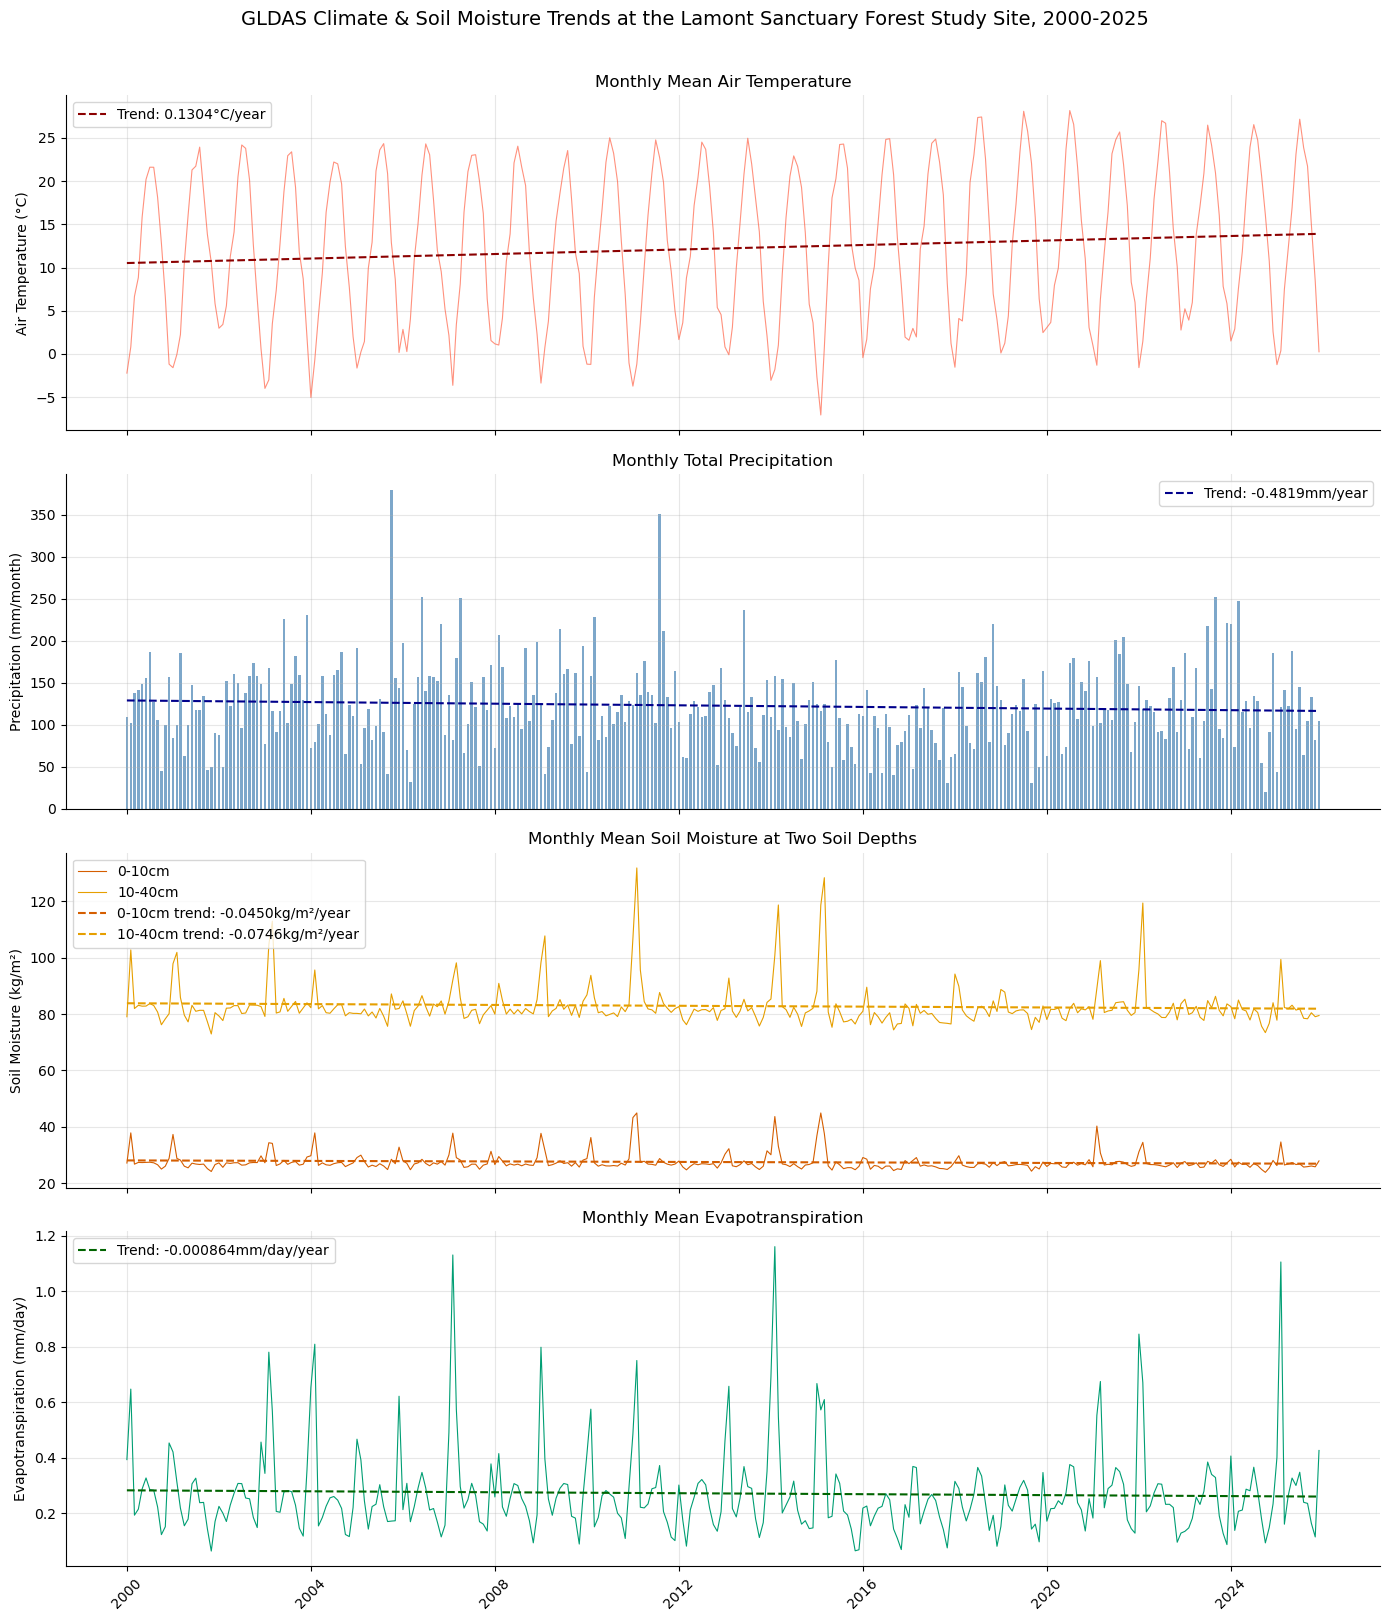

        Mean Temp (°C)  Mean Precip (mm/day)  Soil Moisture 0-10cm (kg/m²)  Soil Moisture 10-40cm (kg/m²)  Mean ET (mm/day)
season                                                                                                                     
Winter            0.98                  4.08                         30.06                          86.87              0.38
Spring           10.44                  3.91                         26.98                          83.24              0.24
Summer           23.33                  4.29                         26.65                          81.26              0.29
Fall             14.12                  3.86                         26.15                          79.91              0.16


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# -----------------------------------------------
# Panel 1: Temperature
# -----------------------------------------------
axes[0].plot(df_gldas_monthly['date_ts'], df_gldas_monthly['Tair_C'],
             color='tomato', linewidth=0.8, alpha=0.7)
# Fit a linear trend line to the data using least squares polynomial fitting
z_temp = np.polyfit(range(len(df_gldas_monthly)), df_gldas_monthly['Tair_C'], 1)
p_trend_temp = np.poly1d(z_temp)
slope_temp = z_temp[0] # Calculate slope
axes[0].plot(df_gldas_monthly['date_ts'], p_trend_temp(range(len(df_gldas_monthly))),
             color='darkred', linewidth=1.5, linestyle='--', 
             label=f'Trend: {slope_temp * 12:.4f}°C/year')
#Add labels and legend
axes[0].set_ylabel('Air Temperature (°C)')
axes[0].set_title('Monthly Mean Air Temperature')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -----------------------------------------------
# Panel 2: Precipitation
# -----------------------------------------------
axes[1].bar(df_gldas_monthly['date_ts'], df_gldas_monthly['Rainf_mm_day'],
            color='steelblue', alpha=0.7, width=20)
# Fit a linear trend line to the data using least squares polynomial fitting
z_prcp = np.polyfit(range(len(df_gldas_monthly)), df_gldas_monthly['Rainf_mm_day'], 1)
p_trend_prcp = np.poly1d(z_prcp)
slope_prcp = z_prcp[0] # Calculate slope
axes[1].plot(df_gldas_monthly['date_ts'], p_trend_prcp(range(len(df_gldas_monthly))),
             color='darkblue', linewidth=1.5, linestyle='--',
             label=f'Trend: {slope_prcp * 12:.4f}mm/year')
#Add labels and legend
axes[1].set_ylabel('Precipitation (mm/month)')
axes[1].set_title('Monthly Total Precipitation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# -----------------------------------------------
# Panel 3: Soil Moisture
# -----------------------------------------------
axes[2].plot(df_gldas_monthly['date_ts'], df_gldas_monthly['SoilMoi0_10cm_inst'],
             color='#D55E00', linewidth=0.8, label='0-10cm')
axes[2].plot(df_gldas_monthly['date_ts'], df_gldas_monthly['SoilMoi10_40cm_inst'],
             color='#E69F00', linewidth=0.8, label='10-40cm')
# Fit a linear trend line to the data using least squares polynomial fitting for each soil depth
z_soil1 = np.polyfit(range(len(df_gldas_monthly)), df_gldas_monthly['SoilMoi0_10cm_inst'], 1)
z_soil2 = np.polyfit(range(len(df_gldas_monthly)), df_gldas_monthly['SoilMoi10_40cm_inst'], 1)
p_trend_soil1 = np.poly1d(z_soil1)
p_trend_soil2 = np.poly1d(z_soil2)
slope_soil1 = z_soil1[0] # calculate slope for 0-10 depth
slope_soil2 = z_soil2[0] # calculate slope for 10-20 depth
axes[2].plot(df_gldas_monthly['date_ts'], p_trend_soil1(range(len(df_gldas_monthly))),
             color='#D55E00', linewidth=1.5, linestyle='--',
             label=f'0-10cm trend: {slope_soil1 * 12:.4f}kg/m²/year')
axes[2].plot(df_gldas_monthly['date_ts'], p_trend_soil2(range(len(df_gldas_monthly))),
             color='#E69F00', linewidth=1.5, linestyle='--',
             label=f'10-40cm trend: {slope_soil2 * 12:.4f}kg/m²/year')
#Add labels and legend
axes[2].set_ylabel('Soil Moisture (kg/m²)')
axes[2].set_title('Monthly Mean Soil Moisture at Two Soil Depths')
axes[2].legend(loc = 'upper left')
axes[2].grid(True, alpha=0.3)

# -----------------------------------------------
# Panel 4: Evapotranspiration
# -----------------------------------------------
axes[3].plot(df_gldas_monthly['date_ts'], df_gldas_monthly['Evap_mm_day'],
             color='#009E73', linewidth=0.8)
# Fit a linear trend line to the data using least squares polynomial fitting
z_et = np.polyfit(range(len(df_gldas_monthly)), df_gldas_monthly['Evap_mm_day'], 1)
p_trend_et = np.poly1d(z_et)
slope_et = z_et[0]
axes[3].plot(df_gldas_monthly['date_ts'], p_trend_et(range(len(df_gldas_monthly))),
             color='darkgreen', linewidth=1.5, linestyle='--',
             label=f'Trend: {slope_et * 12:.6f}mm/day/year')
#Add labels and legend
axes[3].set_ylabel('Evapotranspiration (mm/day)')
axes[3].set_title('Monthly Mean Evapotranspiration')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# -----------------------------------------------
# Display plots
# -----------------------------------------------

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GLDAS Climate & Soil Moisture Trends at the Lamont Sanctuary Forest Study Site, 2000-2025',
             fontsize=14, y=1.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------------------
# Create table of seasonal averages
# -----------------------------------------------

# Seasonal averages table from GLDAS
df_gldas['season'] = df_gldas['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Fall', 10:'Fall', 11:'Fall'})

# Group by season
seasonal_gldas = df_gldas.groupby('season').agg({
    'Tair_C': 'mean',
    'Rainf_mm_day': 'mean',
    'SoilMoi0_10cm_inst': 'mean',
    'SoilMoi10_40cm_inst': 'mean',
    'Evap_mm_day': 'mean'
}).round(2)

# Reorder seasons
seasonal_gldas = seasonal_gldas.loc[['Winter', 'Spring', 'Summer', 'Fall']]

# Shorten column names
seasonal_gldas.columns = [
    'Mean Temp (°C)',
    'Mean Precip (mm/day)',
    'Soil Moisture 0-10cm (kg/m²)',
    'Soil Moisture 10-40cm (kg/m²)',
    'Mean ET (mm/day)'
]

#Print table
print(seasonal_gldas.to_string())

Takeaways from GLDAS plots and season table:
- Air temperature shows a positive trend of +0.13°C/year, consistent with 
  the Daymet-derived warming trend found later in Hypothesis 5. Low temperatures in winter and high temperatures in summer, as expected.
- Precipitation shows a slight negative trend (-0.48mm/year) but with high 
  monthly variability, mostly consistent with the non-significant trend found in Hypothesis 5. Precipitation is quite uniform across seasons.
- Soil moisture is consistently higher at 10-40 cm than 0-10 cm. Soil moisture at both depths shows a slight decreasing trend over the period, which could reflect increased temperatures driving higher water demand  despite relatively stable precipitation. Soil moisture is highest in winter and lowest in fall.
- Evapotranspiration shows a slight negative trend that is almost zero, which may reflect interannual variability rather than a true directional change. Evapotranspiration is highest in winter and lowest in fall, corresponding to soil moisture seasonal changes. However, in deciduous forests, evapotranspiration typicallys peak in summer, so there could be an issue with the evapotranspiration dataset.

Note: GLDAS trends are not formally tested in Hypothesis 5 because the Daymet 
dataset provides higher spatial resolution (1km vs 25km) and is observation-based 
rather than modeled, making it more appropriate for trend analysis at the fine 
scale of the LSF study site. GLDAS climate variables (temperature, precipitation, 
soil moisture) are used for NDVI hypothesis testing (H1,H2,H3) to allow all three 
drivers to be extracted from a single consistent dataset, and for regional soil 
moisture context in Hypothesis 6.

## Testing Hypotheses 1, 2, and 3

I created Pearson correlation scatterplots between air temperature and NDVI (Hyp 1), soil moisture and NDVI (Hyp 2), precipitation and NDVI (Hyp 3) at Lamont Sanctuary Forest from 2000-2024 to determine whether those variables have a significant relationship. I also created boxplots of the seasonal differences for those variables. Climate variables for NDVI hypothesis testing were sourced from GLDAS since it provides soil moisture data not available in Daymet, allowing all three  climate drivers to be extracted from a single consistent dataset matched to each 
date in Landsat for NDVI values.

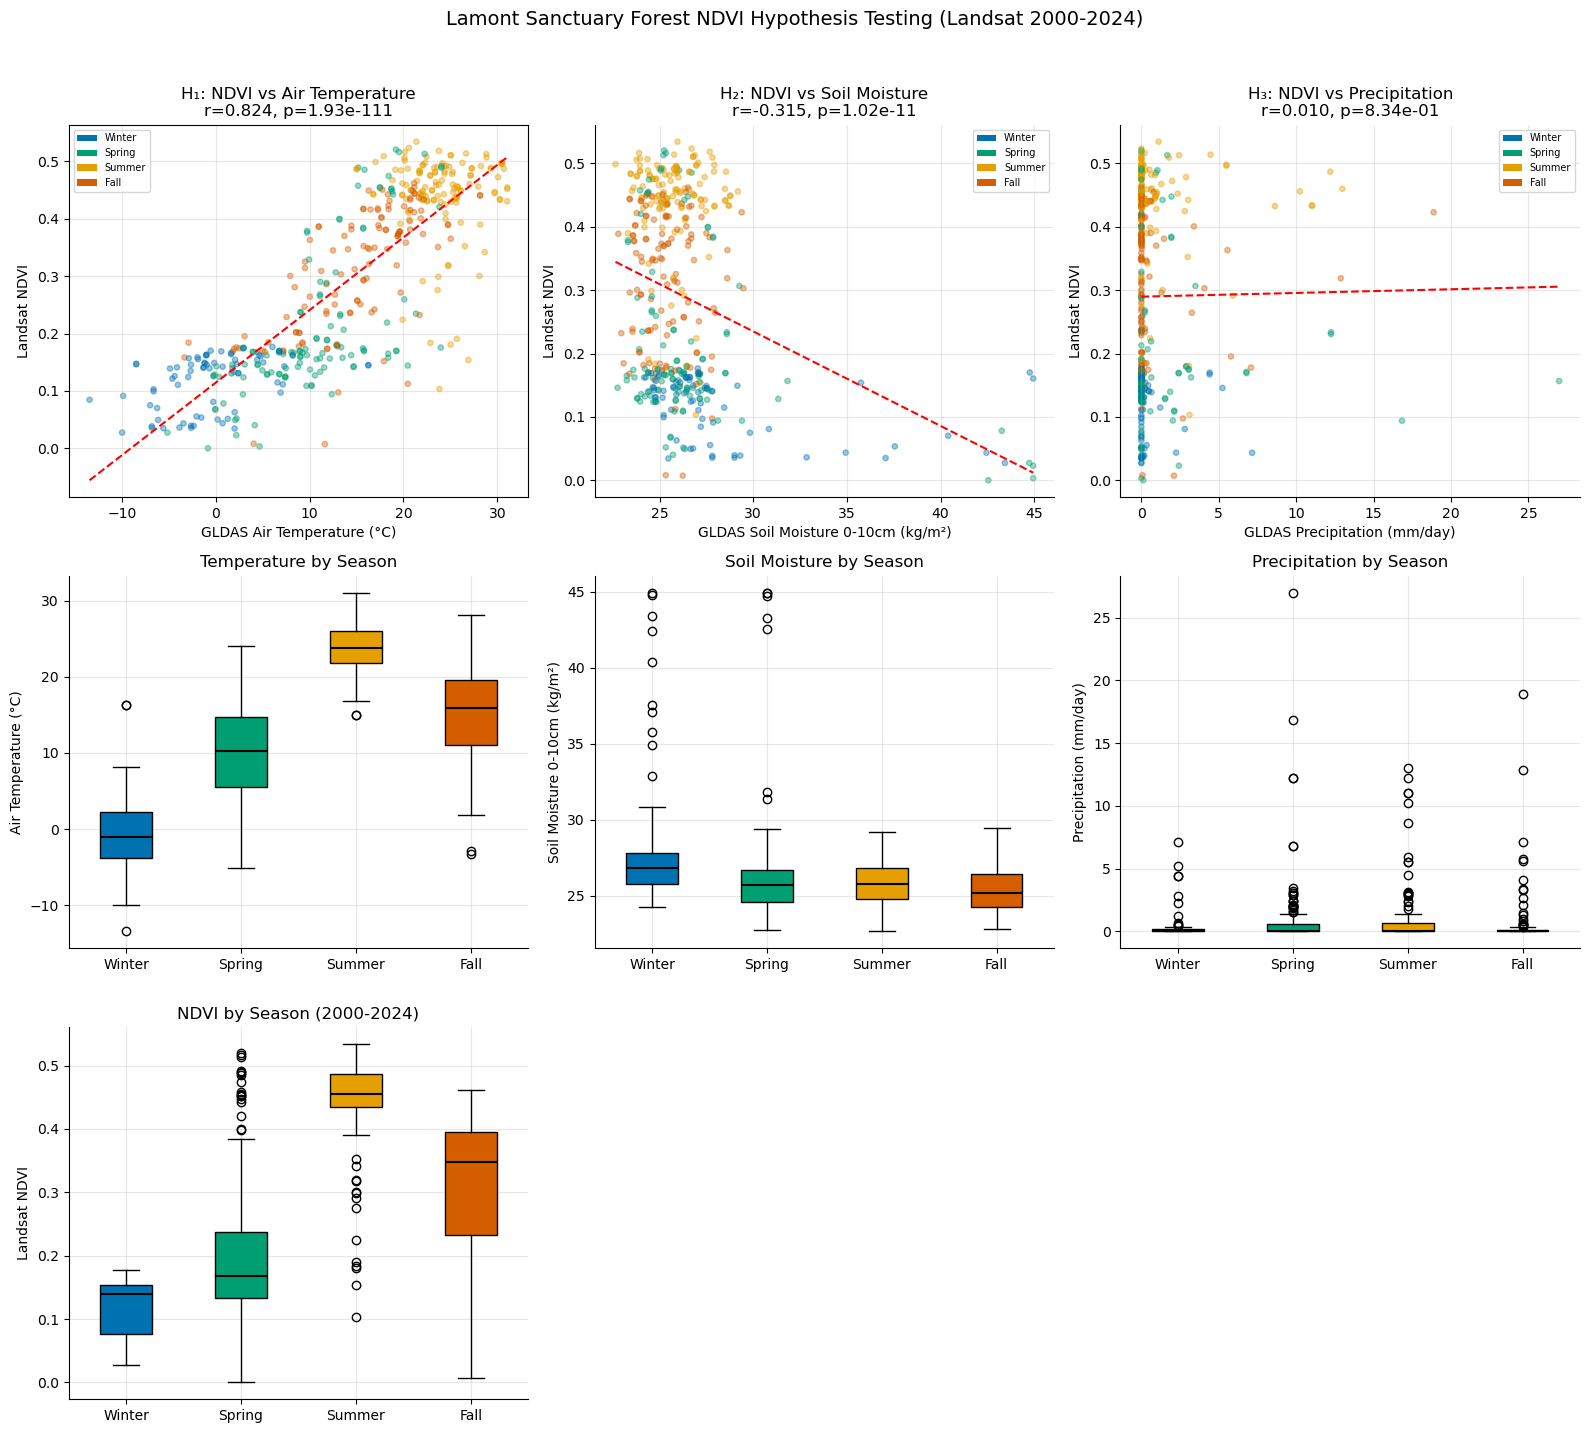

NDVI Hypothesis Test Results:
H₁ - NDVI vs Temperature:    r=0.824, p=1.93e-111 Reject H₀
H₂ - NDVI vs Soil Moisture:  r=-0.315, p=1.02e-11 Reject H₀
H₃ - NDVI vs Precipitation:  r=0.010, p=8.34e-01 Fail to reject H₀


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

# ---------------------------------------------------------------
# Top row - scatter plots:
# ---------------------------------------------------------------

# Define season colors
season_colors = {
    'Winter': '#0072B2',  # blue
    'Spring': '#009E73',  # teal
    'Summer': '#E69F00',  # yellow-orange
    'Fall':   '#D55E00'   # vermillion
}

# Map colors to each row
point_colors = df_ndvi_soil['season'].map(season_colors)

# -----------------------------------------------
# Panel 1: NDVI vs Temperature (Alt Hyp 1)
# -----------------------------------------------
ax = axes[0, 0]
scatter = ax.scatter(df_ndvi_soil['Tair_C'], df_ndvi_soil['NDVI'],
                     color=point_colors,
                     alpha=0.4, s=15)
# Fit a linear trend line to the data using least squares polynomial fitting
z1 = np.polyfit(df_ndvi_soil['Tair_C'], df_ndvi_soil['NDVI'], 1)
p_fit1 = np.poly1d(z1)
x_line = np.linspace(df_ndvi_soil['Tair_C'].min(), df_ndvi_soil['Tair_C'].max(), 100)
ax.plot(x_line, p_fit1(x_line), 'r--', linewidth=1.5)
r1, p1 = stats.pearsonr(df_ndvi_soil['NDVI'], df_ndvi_soil['Tair_C'])
ax.set_xlabel('GLDAS Air Temperature (°C)')
ax.set_ylabel('Landsat NDVI')
ax.set_title(f'H₁: NDVI vs Air Temperature\nr={r1:.3f}, p={p1:.2e}')
ax.grid(True, alpha=0.3)

#Create legend
legend_elements = [Patch(facecolor=color, label=season) 
                   for season, color in season_colors.items()]
ax.legend(handles=legend_elements, fontsize=7, loc='upper left')

# -----------------------------------------------
# Panel 2: NDVI vs Soil Moisture (Alt Hyp 2)
# -----------------------------------------------
ax = axes[0, 1]
ax.scatter(df_ndvi_soil['SoilMoi0_10cm_inst'], df_ndvi_soil['NDVI'],
           color=point_colors,
           alpha=0.4, s=15)
# Fit a linear trend line to the data using least squares polynomial fitting
z2 = np.polyfit(df_ndvi_soil['SoilMoi0_10cm_inst'], df_ndvi_soil['NDVI'], 1)
p_fit2 = np.poly1d(z2)
x_line = np.linspace(df_ndvi_soil['SoilMoi0_10cm_inst'].min(),
                     df_ndvi_soil['SoilMoi0_10cm_inst'].max(), 100)
ax.plot(x_line, p_fit2(x_line), 'r--', linewidth=1.5)
r2, p2 = stats.pearsonr(df_ndvi_soil['NDVI'], df_ndvi_soil['SoilMoi0_10cm_inst'])
ax.set_xlabel('GLDAS Soil Moisture 0-10cm (kg/m²)')
ax.set_ylabel('Landsat NDVI')
ax.set_title(f'H₂: NDVI vs Soil Moisture\nr={r2:.3f}, p={p2:.2e}')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Create legend
legend_elements = [Patch(facecolor=color, label=season) 
                   for season, color in season_colors.items()]
ax.legend(handles=legend_elements, fontsize=7, loc='upper right')

# -----------------------------------------------
# Panel 3: NDVI vs Precipitation (Alt Hyp 3)
# -----------------------------------------------
ax = axes[0, 2]
ax.scatter(df_ndvi_soil['Rainf_mm_day'], df_ndvi_soil['NDVI'],
           color=point_colors,
           alpha=0.4, s=15)
# Fit a linear trend line to the data using least squares polynomial fitting
z3 = np.polyfit(df_ndvi_soil['Rainf_mm_day'], df_ndvi_soil['NDVI'], 1)
p_fit3 = np.poly1d(z3)
x_line = np.linspace(df_ndvi_soil['Rainf_mm_day'].min(),
                     df_ndvi_soil['Rainf_mm_day'].max(), 100)
ax.plot(x_line, p_fit3(x_line), 'r--', linewidth=1.5)
r3, p3 = stats.pearsonr(df_ndvi_soil['NDVI'], df_ndvi_soil['Rainf_mm_day'])
ax.set_xlabel('GLDAS Precipitation (mm/day)')
ax.set_ylabel('Landsat NDVI')
ax.set_title(f'H₃: NDVI vs Precipitation\nr={r3:.3f}, p={p3:.2e}')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create legend
legend_elements = [Patch(facecolor=color, label=season) 
                   for season, color in season_colors.items()]
ax.legend(handles=legend_elements, fontsize=7, loc='upper right')

# ---------------------------------------------------------------
# Bottom row - seasonal breakdown boxplots:
# ---------------------------------------------------------------
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Panel 4 - NDVI by season (Temperature context)
ax = axes[1, 0]
season_temp = [df_ndvi_soil[df_ndvi_soil['season'] == s]['Tair_C'].values 
               for s in season_order]
# Create boxplot
bp = ax.boxplot(season_temp, tick_labels=season_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))

colors = ['#0072B2', '#009E73', '#E69F00', '#D55E00']  # Winter, Spring, Summer, Fall
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('Temperature by Season')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------------------------
# Panel 5: Soil moisture by season
# -----------------------------------------------
ax = axes[1, 1]
season_soil = [df_ndvi_soil[df_ndvi_soil['season'] == s]['SoilMoi0_10cm_inst'].values 
               for s in season_order]
# Create boxplot
bp = ax.boxplot(season_soil, tick_labels=season_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Soil Moisture 0-10cm (kg/m²)')
ax.set_title('Soil Moisture by Season')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------------------------
# Panel 6: Precipitation by season
# -----------------------------------------------
ax = axes[1, 2]
season_prcp = [df_ndvi_soil[df_ndvi_soil['season'] == s]['Rainf_mm_day'].values 
               for s in season_order]
# Create boxplot
bp = ax.boxplot(season_prcp, tick_labels=season_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('Precipitation by Season')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------------------------
# Bottom row: NDVI by season
# -----------------------------------------------

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

season_ndvi = [df_ndvi_soil[df_ndvi_soil['season'] == s]['NDVI'].values 
               for s in season_order]
# Create boxplot
bp = axes[2, 0].boxplot(season_ndvi, tick_labels=season_order, patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[2, 0].set_ylabel('Landsat NDVI')
axes[2, 0].set_title('NDVI by Season (2000-2024)')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].spines['top'].set_visible(False)
axes[2, 0].spines['right'].set_visible(False)


plt.suptitle('Lamont Sanctuary Forest NDVI Hypothesis Testing (Landsat 2000-2024)', fontsize=14,y=1.02)
plt.subplots_adjust(top=0.88)
plt.tight_layout()
plt.show()

# Print summary
print("NDVI Hypothesis Test Results:")
print(f"H₁ - NDVI vs Temperature:    r={r1:.3f}, p={p1:.2e} {'Reject H₀' if p1 < 0.05 else 'Fail to reject H₀'}")
print(f"H₂ - NDVI vs Soil Moisture:  r={r2:.3f}, p={p2:.2e} {'Reject H₀' if p2 < 0.05 else 'Fail to reject H₀'}")
print(f"H₃ - NDVI vs Precipitation:  r={r3:.3f}, p={p3:.2e} {'Reject H₀' if p3 < 0.05 else 'Fail to reject H₀'}")

In [7]:
seasonal_summary = df_ndvi_soil.groupby('season').agg({
    'NDVI': 'mean',
    'Tair_C': 'mean',
    'SoilMoi0_10cm_inst': 'mean',
    'Rainf_mm_day': 'mean'
}).round(3)

# Reorder seasons and print seasonal summary for mean values of NDVI, temp, soil moisture, and precipitation
seasonal_summary = seasonal_summary.loc[['Winter', 'Spring', 'Summer', 'Fall']]
seasonal_summary.columns = ['Mean NDVI', 'Mean Temp (°C)', 
                             'Mean Soil Moisture (kg/m²)', 'Mean Precip (mm/day)']
print(seasonal_summary)

        Mean NDVI  Mean Temp (°C)  Mean Soil Moisture (kg/m²)  \
season                                                          
Winter      0.117          -0.346                      28.329   
Spring      0.209          10.436                      26.514   
Summer      0.442          24.078                      25.794   
Fall        0.311          14.938                      25.362   

        Mean Precip (mm/day)  
season                        
Winter                 0.430  
Spring                 1.101  
Summer                 1.013  
Fall                   0.645  


## Explore Gridded Soil Moisture Data prior to testing Hypothesis 4
This includes displaying gridded soil moisture in units of % Volumetric Water Content across 121 LSF TDR grid points for 8 dates in August 2024 and June-July 2025.

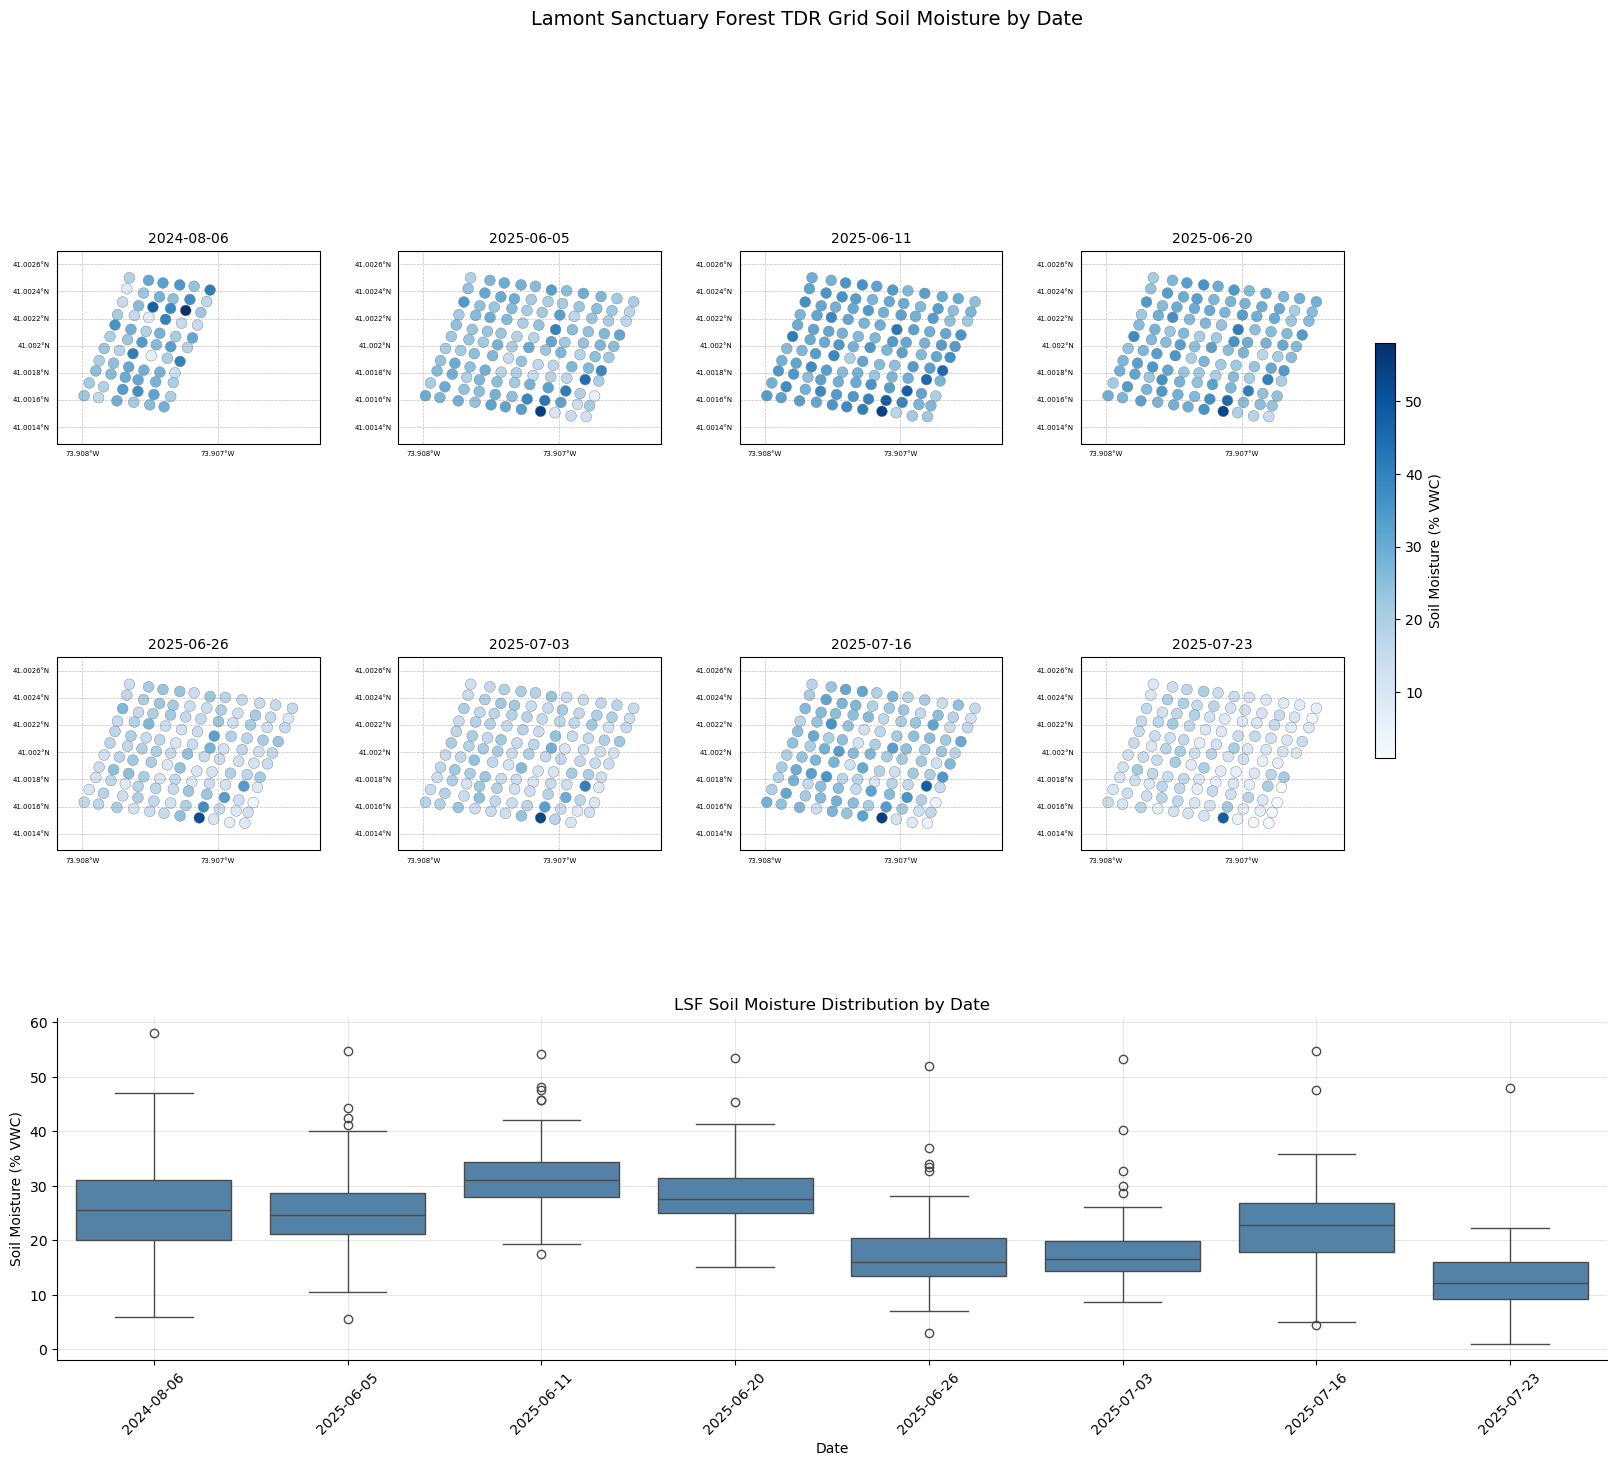

In [8]:
# Axis limits
lon_min = df_grid_all['longitude'].min() - 0.0002
lon_max = df_grid_all['longitude'].max() + 0.0002
lat_min = df_grid_all['latitude'].min() - 0.0002
lat_max = df_grid_all['latitude'].max() + 0.0002

# Dates and color scale
dates = sorted(df_grid_all['Date'].unique())
vmin = df_grid_all['Soil Moisture (VWC)'].min()
vmax = df_grid_all['Soil Moisture (VWC)'].max()

# Grid dimensions
n_dates = len(dates)
ncols = 4
nrows = (n_dates + ncols - 1) // ncols

fig = plt.figure(figsize=(20, (nrows + 1) * 5))
gs = gridspec.GridSpec(nrows + 1, ncols, 
                       figure=fig,
                       hspace=0.4, wspace=0.3,
                       height_ratios=[1] * nrows + [1.2])

# Grid map subplots with PlateCaree projection
map_axes = []

# This For Loop iterates over each sampling date and creates a spatial map of soil moisture.
for i, date in enumerate(dates):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
    map_axes.append(ax)
    
    subset = df_grid_all[df_grid_all['Date'] == date]
    # check if the lat and lon are available
    if 'latitude' in subset.columns and subset['latitude'].notna().any():
        sc = ax.scatter(subset['longitude'], subset['latitude'],
                       c=subset['Soil Moisture (VWC)'],
                       cmap='Blues', vmin=vmin, vmax=vmax,
                       s=60, edgecolors='gray', linewidth=0.3,
                       transform=ccrs.PlateCarree())
        # fix the extent so all maps are the same size
        ax.set_extent([lon_min, lon_max, lat_min, lat_max],
                      crs=ccrs.PlateCarree())
        # add coordinate gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                          color='gray', alpha=0.5, linestyle='--')
        # hide top and right labels to reduce clutter
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 5}
        gl.ylabel_style = {'size': 5}
        gl.xlocator = mticker.FixedLocator([-73.908, -73.907, -73.906, -73.905])
        # format as degrees longitude and latitude
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
    # set date as title
    ax.set_title(pd.Timestamp(date).strftime('%Y-%m-%d'), fontsize=10)

# Create one colorbar for all grid maps
sm = plt.cm.ScalarMappable(cmap='Blues',
                            norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, ax=map_axes,
                    label='Soil Moisture (% VWC)',
                    shrink=0.6, pad=0.02)

# Create boxplot spanning full bottom row, with boxes for each of the 8 dates
ax_box = fig.add_subplot(gs[nrows, :])
sns.boxplot(data=df_grid_combined, x='Date_str', y='Soil Moisture (VWC)',
            color='steelblue', ax=ax_box)
ax_box.set_title('LSF Soil Moisture Distribution by Date')
ax_box.set_xlabel('Date')
ax_box.set_ylabel('Soil Moisture (% VWC)')
ax_box.tick_params(axis='x', rotation=45)
ax_box.grid(True, alpha=0.3)
ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)

plt.suptitle('Lamont Sanctuary Forest TDR Grid Soil Moisture by Date', fontsize=14, y=1.01)
plt.show()

These plots show the spatial variability in soil moisture across the LSF study site across 8 different dates based on TDR grid measurements.

Note: 2024-08-06 only shows half of the points relative to the other plots because soil moisture was only measured at half of the sites on that date.

## Testing Hypothesis 4

Null Hyp: There is no significant relationship between soil moisture and canopy height.

Alt Hyp: Grid points with taller canopy have significantly different soil moisture than points with shorter canopy.

Note: There is a temporal difference of five years between these datasets:
- Canopy height is a single snapshot from a date sometime between 2018 and 2020
- Soil moisture is averaged across Aug 2024 and Jun-Jul 2025

Additionally, since the Meta/WRI canopy height map represents a single snapshot in time, it cannot be used to assess temporal changes in canopy structure. 
Analysis is therefore limited to spatial correlation between canopy 
height and soil moisture across the TDR grid.

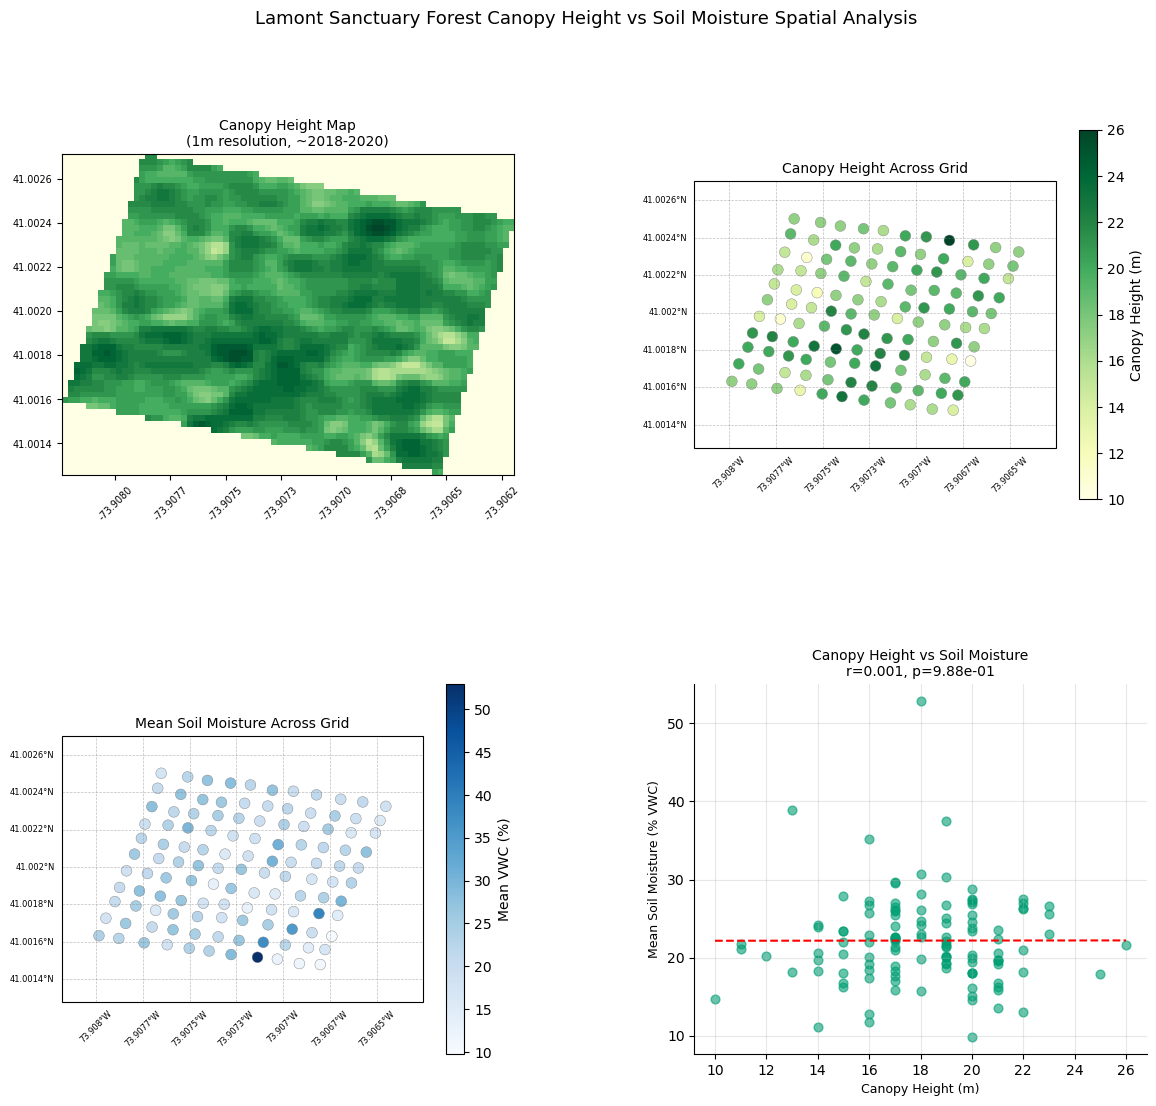

Null Hypothesis 4: Canopy height has no significant effect on soil moisture

Approach 1 - Pearson Correlation (linear relationship):
r=0.001, p=9.88e-01 — Fail to reject H₀

Approach 2 - Independent t-test (tall vs short canopy):
Median canopy height: 18.0m
Tall canopy (>=18.0m) mean VWC: 22.41% (n=68)
Short canopy (<18.0m) mean VWC: 21.87% (n=53)
t=0.512, p=0.6093 — Fail to reject H₀

Conclusion: Both approaches fail to reject H₀. Canopy height does
not significantly predict soil moisture at the LSF study site.


In [9]:
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 2, wspace=0.4, hspace=0.5)

# -----------------------------------------------
# Panel 1 - Canopy height raster
# -----------------------------------------------
ax_raster = fig.add_subplot(gs[0, 0])
# Open and display the canopy height GeoTIFF raster 
with rasterio.open('CanopyHeight_LSF.tif') as src:
    show(src, ax=ax_raster, cmap='YlGn')
# Format title and axes 
ax_raster.set_title('Canopy Height Map\n(1m resolution, ~2018-2020)', fontsize=10)
ax_raster.xaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
ax_raster.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
ax_raster.tick_params(axis='x', rotation=45, labelsize=7)
ax_raster.tick_params(axis='y', labelsize=7)

# -----------------------------------------------
# Panel 2 - Canopy height spatial map
# -----------------------------------------------
# Use PlateCarree projection
ax_map1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
sc1 = ax_map1.scatter(df_canopy_soil['longitude'], df_canopy_soil['latitude'],
                      c=df_canopy_soil['canopy_height'],
                      cmap='YlGn', s=60, edgecolors='gray', linewidth=0.3,
                     transform=ccrs.PlateCarree())
ax_map1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

gl = ax_map1.gridlines(draw_labels=True, linewidth=0.5,
                        color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 6, 'rotation': 45}
gl.ylabel_style = {'size': 6}

#create colorbar
plt.colorbar(sc1, ax=ax_map1, label='Canopy Height (m)')
ax_map1.set_title('Canopy Height Across Grid', fontsize=10)
ax_map1.grid(True, alpha=0.3)

# -----------------------------------------------
# Panel 3 - Soil moisture spatial map
# -----------------------------------------------
# Use PlateCarree projection
ax_map2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
sc2 = ax_map2.scatter(df_canopy_soil['longitude'], df_canopy_soil['latitude'],
                      c=df_canopy_soil['mean_VWC'],
                      cmap='Blues', s=60, edgecolors='gray', linewidth=0.3,
                     transform=ccrs.PlateCarree())
ax_map2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

gl = ax_map2.gridlines(draw_labels=True, linewidth=0.5,
                        color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 6, 'rotation': 45}
gl.ylabel_style = {'size': 6}

#create colorbar
plt.colorbar(sc2, ax=ax_map2, label='Mean VWC (%)')
ax_map2.set_title('Mean Soil Moisture Across Grid', fontsize=10)
ax_map2.grid(True, alpha=0.3)

# -----------------------------------------------
# Panel 4 - Scatter correlation
# -----------------------------------------------
# create satter plot of canopy height vs mean soil moisture across all TDR grid points
ax_scatter = fig.add_subplot(gs[1, 1])
ax_scatter.scatter(df_canopy_soil['canopy_height'], df_canopy_soil['mean_VWC'],
                   alpha=0.6, color='#009E73', s=40)
# Fit a linear trend line to the data
z_canopy = np.polyfit(df_canopy_soil['canopy_height'], df_canopy_soil['mean_VWC'], 1)
p_fit_canopy = np.poly1d(z_canopy)
# Create 100 evenly spaced x-values across the canopy height range for a smooth trend line
x_line_canopy = np.linspace(df_canopy_soil['canopy_height'].min(),
                             df_canopy_soil['canopy_height'].max(), 100)
#plot the trend line
ax_scatter.plot(x_line_canopy, p_fit_canopy(x_line_canopy), 'r--', linewidth=1.5)

# Canopy height correlation
r_canopy, p_canopy = stats.pearsonr(df_canopy_soil['canopy_height'], 
                                     df_canopy_soil['mean_VWC'])
ax_scatter.set_xlabel('Canopy Height (m)', fontsize=9)
ax_scatter.set_ylabel('Mean Soil Moisture (% VWC)', fontsize=9)
ax_scatter.set_title(f'Canopy Height vs Soil Moisture\nr={r_canopy:.3f}, p={p_canopy:.2e}', fontsize=10)
ax_scatter.grid(True, alpha=0.3)

# Remove top and right borders
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)

# -----------------------------------------------
# Show plots
# -----------------------------------------------

plt.suptitle('Lamont Sanctuary Forest Canopy Height vs Soil Moisture Spatial Analysis', fontsize=13)
plt.show()

# -----------------------------------------------
# Conduct a t-test of tall vs short canopies and soil moisture
# -----------------------------------------------

# Determine median height
median_height = df_canopy_soil['canopy_height'].median()

# Split into tall vs short based on median canopy height
tall = df_canopy_soil[df_canopy_soil['canopy_height'] >= median_height]['mean_VWC']
short = df_canopy_soil[df_canopy_soil['canopy_height'] < median_height]['mean_VWC']

t_stat, p_val = stats.ttest_ind(tall, short)

# -----------------------------------------------
# Print results of the hypothesis testing
# -----------------------------------------------

print("Null Hypothesis 4: Canopy height has no significant effect on soil moisture")
print("=" * 60)
print("\nApproach 1 - Pearson Correlation (linear relationship):")
print(f"r={r_canopy:.3f}, p={p_canopy:.2e} — Fail to reject H₀")
print("\nApproach 2 - Independent t-test (tall vs short canopy):")
print(f"Median canopy height: {median_height}m")
print(f"Tall canopy (>={median_height}m) mean VWC: {tall.mean():.2f}% (n={len(tall)})")
print(f"Short canopy (<{median_height}m) mean VWC: {short.mean():.2f}% (n={len(short)})")
print(f"t={t_stat:.3f}, p={p_val:.4f} — Fail to reject H₀")
print("\nConclusion: Both approaches fail to reject H₀. Canopy height does")
print("not significantly predict soil moisture at the LSF study site.")

## Testing Hypothesis 5
Null Hyp: No significant trend in temperature or precipitation at LSF (2000-2024).

Alt Hyp: Significant increase in temperature while no significant change in precipitation at LSF (2000-2024).

Data source: Daymet V4

Long-term Trends (2000-2024):
  Tmax: 0.0352°C/year, r=0.399, p=0.0483
  Tmin: 0.0485°C/year, r=0.499, p=0.0111
  Precipitation: 2.88mm/year, r=0.100, p=0.6342


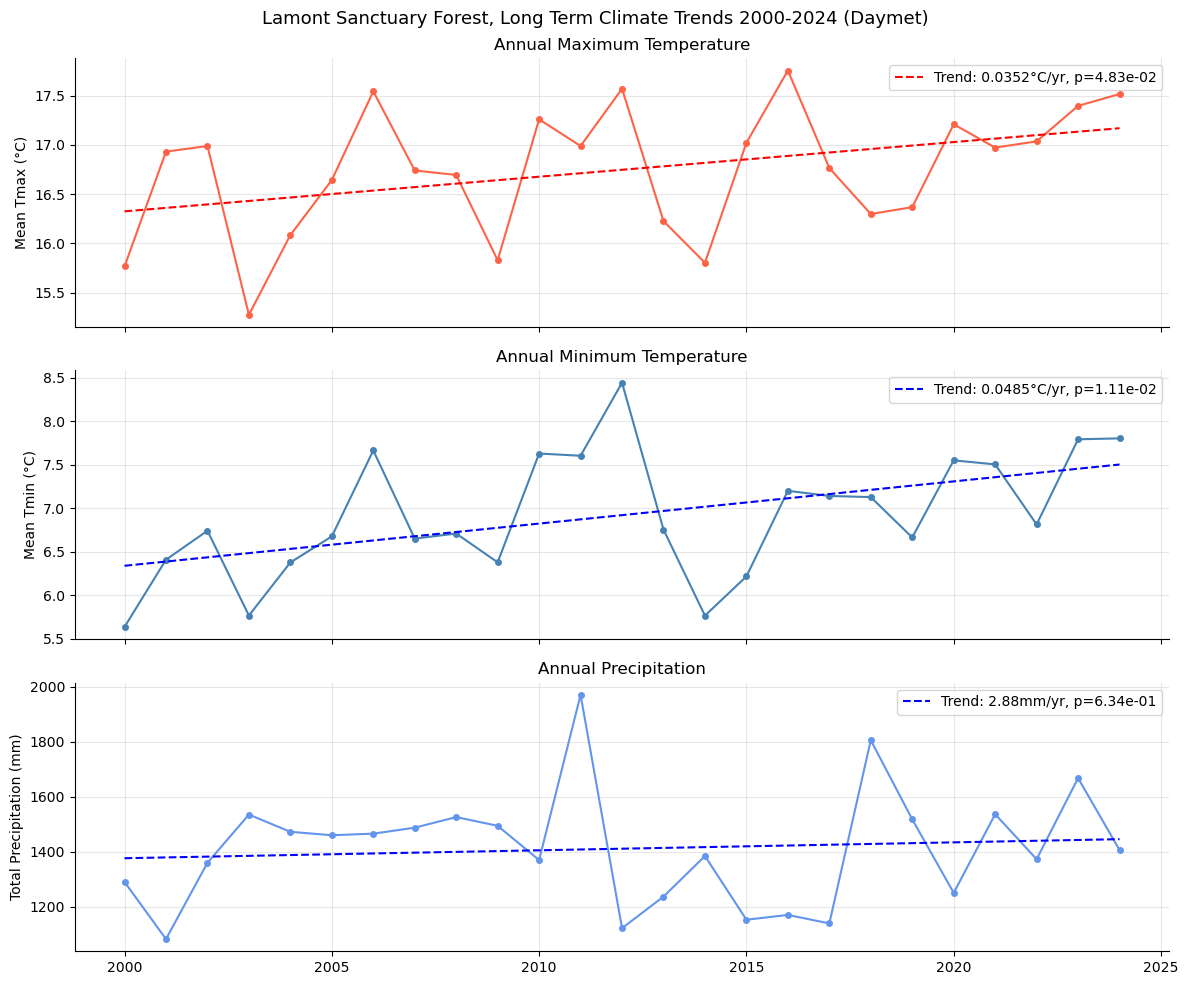

Null Hypothesis 5: No significant trend in temperature or precipitation at LSF (2000-2024)
Tmax trend: 0.0352°C/year, p=4.83e-02 — Reject H₀
Tmin trend: 0.0485°C/year, p=1.11e-02 — Reject H₀
Precipitation trend: 2.88mm/year, p=6.34e-01 — Fail to reject H₀

Conclusion: Both Tmax and Tmin show statistically significant warming trends,
while precipitation shows no significant directional trend over 2000-2024.


In [10]:
df_daymet['year'] = df_daymet['date'].dt.year

# Annual aggregations
annual_tmax = df_daymet.groupby('year')['tmax'].mean()
annual_tmin = df_daymet.groupby('year')['tmin'].mean()
annual_prcp = df_daymet.groupby('year')['prcp'].sum()

# Trend tests
slope_tmax, intercept_tmax, r_tmax, p_tmax, _ = stats.linregress(annual_tmax.index, annual_tmax.values)
slope_tmin, intercept_tmin, r_tmin, p_tmin, _ = stats.linregress(annual_tmin.index, annual_tmin.values)
slope_prcp, intercept_prcp, r_prcp, p_prcp, _ = stats.linregress(annual_prcp.index, annual_prcp.values)

x_line = np.linspace(annual_tmax.index.min(), annual_tmax.index.max(), 100)

print("Long-term Trends (2000-2024):")
print(f"  Tmax: {slope_tmax:.4f}°C/year, r={r_tmax:.3f}, p={p_tmax:.4f}")
print(f"  Tmin: {slope_tmin:.4f}°C/year, r={r_tmin:.3f}, p={p_tmin:.4f}")
print(f"  Precipitation: {slope_prcp:.2f}mm/year, r={r_prcp:.3f}, p={p_prcp:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# -----------------------------------------------
# Create plot of annual max temperature
# -----------------------------------------------
axes[0].plot(annual_tmax.index, annual_tmax.values, 
             color='tomato', linewidth=1.5, marker='o', markersize=4)
axes[0].plot(x_line, slope_tmax * x_line + intercept_tmax,
             'r--', linewidth=1.5, 
             label=f'Trend: {slope_tmax:.4f}°C/yr, p={p_tmax:.2e}')
axes[0].set_ylabel('Mean Tmax (°C)')
axes[0].set_title('Annual Maximum Temperature')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -----------------------------------------------
# Create plot of annual min temperature
# -----------------------------------------------
axes[1].plot(annual_tmin.index, annual_tmin.values,
             color='steelblue', linewidth=1.5, marker='o', markersize=4)
axes[1].plot(x_line, slope_tmin * x_line + intercept_tmin,
             'b--', linewidth=1.5,
             label=f'Trend: {slope_tmin:.4f}°C/yr, p={p_tmin:.2e}')
axes[1].set_ylabel('Mean Tmin (°C)')
axes[1].set_title('Annual Minimum Temperature')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# -----------------------------------------------
# Create plot of annual precipitation
# -----------------------------------------------
axes[2].plot(annual_prcp.index, annual_prcp.values,
             color='cornflowerblue', linewidth=1.5, marker='o', markersize=4)
axes[2].plot(x_line, slope_prcp * x_line + intercept_prcp,
             'b--', linewidth=1.5,
             label=f'Trend: {slope_prcp:.2f}mm/yr, p={p_prcp:.2e}')
axes[2].set_ylabel('Total Precipitation (mm)')
axes[2].set_title('Annual Precipitation')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# -----------------------------------------------
# Display plots
# -----------------------------------------------

# Remove top and right borders 
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Lamont Sanctuary Forest, Long Term Climate Trends 2000-2024 (Daymet)', fontsize=13)
plt.tight_layout()
plt.show()

# -----------------------------------------------
# Print hypothesis test results
# -----------------------------------------------
print("Null Hypothesis 5: No significant trend in temperature or precipitation at LSF (2000-2024)")
print("=" * 70)
print(f"Tmax trend: {slope_tmax:.4f}°C/year, p={p_tmax:.2e} — {'Reject H₀' if p_tmax < 0.05 else 'Fail to reject H₀'}")
print(f"Tmin trend: {slope_tmin:.4f}°C/year, p={p_tmin:.2e} — {'Reject H₀' if p_tmin < 0.05 else 'Fail to reject H₀'}")
print(f"Precipitation trend: {slope_prcp:.2f}mm/year, p={p_prcp:.2e} — {'Reject H₀' if p_prcp < 0.05 else 'Fail to reject H₀'}")
print("\nConclusion: Both Tmax and Tmin show statistically significant warming trends,")
print("while precipitation shows no significant directional trend over 2000-2024.")

## Testing Hypothesis 6

Null Hyp: GLDAS-modeled soil moisture accurately represents fine-scale soil moisture variability at the Lamont Sanctuary Forest.

Alt Hyp: GLDAS-modeled soil moisture does not accurately capture fine-scale soil moisture variability at the Lamont Sanctuary Forest due to its coarse 25km resolution.

I also created graphs to compare soil moisture values from three different data sources: GLDAS, sensor data, and TDR grid data. Note that the ground measurements, sensor data and the TDR grid data, do not have temporal overlap.

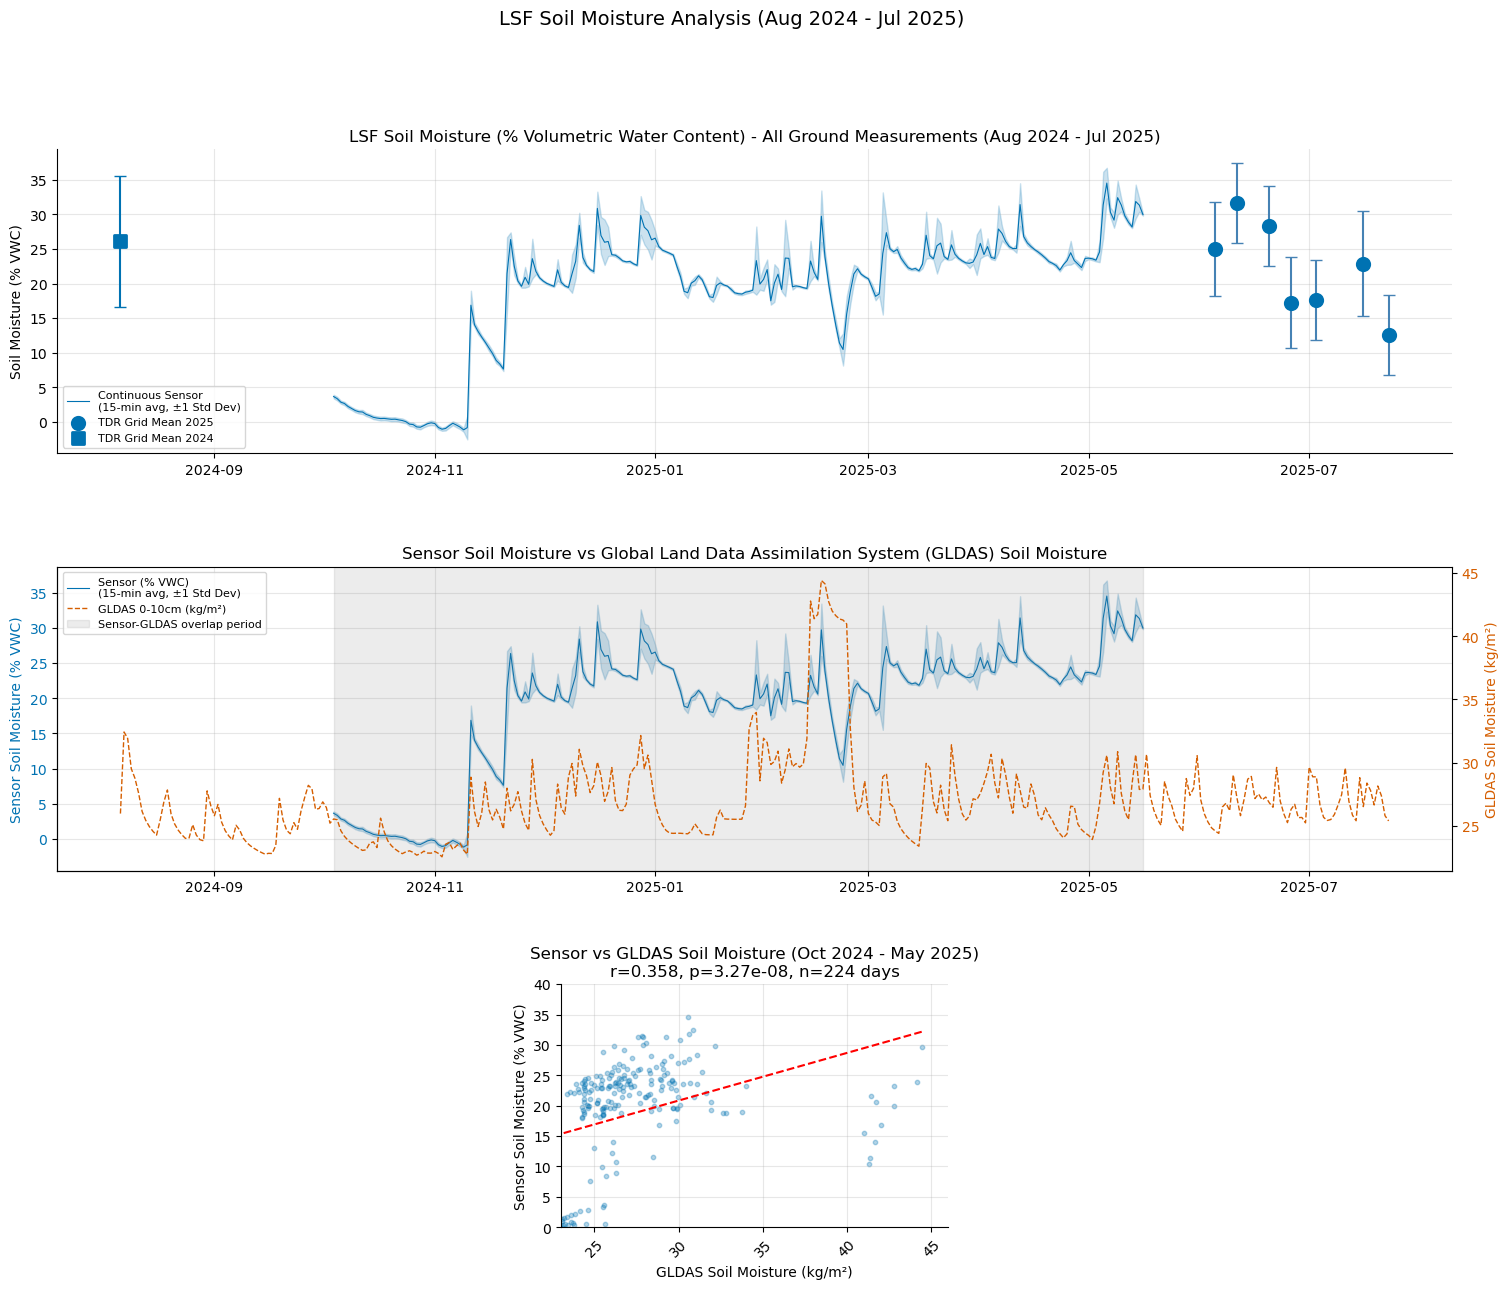

Sensor vs GLDAS Soil Moisture (Null Hypothesis 6):
H₀: GLDAS accurately represents fine-scale soil moisture variability at LSF
r=0.358, p=3.27e-08
Reject H₀. While the correlation is statistically significant, the weak
r²=0.128 indicates GLDAS explains only 12.8% of fine-scale soil
moisture variability, suggesting poor representation at the site scale.


In [16]:
# Convert to numeric first
df_grid_2024['Soil Moisture (VWC)'] = pd.to_numeric(df_grid_2024['Soil Moisture (VWC)'], errors='coerce')
df_grid_2025['Soil Moisture (VWC)'] = pd.to_numeric(df_grid_2025['Soil Moisture (VWC)'], errors='coerce')

# TDR grid averages per date for 2025
df_tdr_2025_avg = df_grid_2025.groupby('Date')['Soil Moisture (VWC)'].mean().reset_index()
df_tdr_2025_std = df_grid_2025.groupby('Date')['Soil Moisture (VWC)'].std().reset_index()

# TDR grid average for 2024
df_tdr_2024_avg = df_grid_2024.groupby('Date')['Soil Moisture (VWC)'].mean().reset_index()
df_tdr_2024_std = df_grid_2024.groupby('Date')['Soil Moisture (VWC)'].std().reset_index()

# Merge the sensor data with GLDAS
df_sensor_daily['date'] = pd.to_datetime(df_sensor_daily['date'])
df_gldas['date'] = pd.to_datetime(df_gldas['date'])


# Set up GridSpec
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, 
                       width_ratios=[3, 1],
                       height_ratios=[1, 1, 0.8],
                       hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])    # Row 1 plot takes full width
ax2 = fig.add_subplot(gs[1, :])    # Row 2 plot takes full width
ax2_twin = ax2.twinx()

gs_bottom = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[2, :])
ax_corr = fig.add_subplot(gs_bottom[0, 1])  # Row 3 plot centered

# -----------------------------------------------
# Panel 1 - All ground soil moisture data combined
# -----------------------------------------------

# Continuous sensor
ax1.plot(df_sensor_daily['date'], df_sensor_daily['sensor_VWC_pct'],
         color='#0072B2', linewidth=0.8, label='Continuous Sensor \n(15-min avg, ±1 Std Dev)')
ax1.fill_between(df_sensor_daily['date'],
                 df_sensor_daily['sensor_VWC_pct'] - df_sensor_daily['sensor_VWC_std_pct'],
                 df_sensor_daily['sensor_VWC_pct'] + df_sensor_daily['sensor_VWC_std_pct'],
                 alpha=0.2, color='#0072B2')

# TDR Grid 2025, mean values with errorbars
ax1.scatter(df_tdr_2025_avg['Date'], df_tdr_2025_avg['Soil Moisture (VWC)'],
            color='#0072B2', zorder=5, s=80, marker='o', linewidth=2,
            label='TDR Grid Mean 2025')
ax1.errorbar(df_tdr_2025_avg['Date'], df_tdr_2025_avg['Soil Moisture (VWC)'],
             yerr=df_tdr_2025_std['Soil Moisture (VWC)'],
             fmt='none', color='steelblue', capsize=4)

# TDR Grid 2024, mean values with errorbars
ax1.scatter(df_tdr_2024_avg['Date'], df_tdr_2024_avg['Soil Moisture (VWC)'],
            facecolors='#0072B2', edgecolors='#0072B2', 
            zorder=5, s=80, marker='s', linewidth=2,
            label='TDR Grid Mean 2024')
ax1.errorbar(df_tdr_2024_avg['Date'], df_tdr_2024_avg['Soil Moisture (VWC)'],
             yerr=df_tdr_2024_std['Soil Moisture (VWC)'],
             fmt='none', color='#0072B2', capsize=4)

ax1.set_ylabel('Soil Moisture (% VWC)')
ax1.set_title('LSF Soil Moisture (% Volumetric Water Content) - All Ground Measurements (Aug 2024 - Jul 2025)')
ax1.legend(loc='lower left', fontsize=8)

# -----------------------------------------------
# Panel 2 - Sensor VWC vs GLDAS kg/m3
# -----------------------------------------------

df_gldas_extended = df_gldas[
    (df_gldas['date'] >= '2024-08-06') & 
    (df_gldas['date'] <= '2025-07-23')
][['date', 'SoilMoi0_10cm_inst', 'Rainf_mm_day']].copy()

# Add full GLDAS soil moisture line Aug 2024 - Jul 2025
ax2_twin.plot(df_gldas_extended['date'], df_gldas_extended['SoilMoi0_10cm_inst'],
              color='#D55E00', linewidth=1.0, linestyle='--',
              label='GLDAS 0-10cm (kg/m²)')

# Highlight overlap period with light gray shading
overlap_start = pd.Timestamp('2024-10-04')
overlap_end = pd.Timestamp('2025-05-16')
ax2_twin.axvspan(overlap_start, overlap_end,
                 alpha=0.15, color='gray', label='Sensor-GLDAS overlap period')

# Sensor line only during overlap period
df_sensor_overlap = df_sensor_daily[
    (df_sensor_daily['date'] >= overlap_start) &
    (df_sensor_daily['date'] <= overlap_end)
]
ax2.plot(df_sensor_overlap['date'], df_sensor_overlap['sensor_VWC_pct'],
         color='#0072B2', linewidth=0.8, label='Sensor (% VWC)\n(15-min avg, ±1 Std Dev)')
ax2.fill_between(df_sensor_overlap['date'],
                 df_sensor_overlap['sensor_VWC_pct'] - df_sensor_overlap['sensor_VWC_std_pct'],
                 df_sensor_overlap['sensor_VWC_pct'] + df_sensor_overlap['sensor_VWC_std_pct'],
                 alpha=0.2, color='#0072B2')

#Add labels
ax2.set_ylabel('Sensor Soil Moisture (% VWC)', color='#0072B2')
ax2_twin.set_ylabel('GLDAS Soil Moisture (kg/m²)', color='#D55E00')
ax2.tick_params(axis='y', labelcolor='#0072B2')
ax2_twin.tick_params(axis='y', labelcolor='#D55E00')
ax2.set_title('Sensor Soil Moisture vs Global Land Data Assimilation System (GLDAS) Soil Moisture')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# -----------------------------------------------
# Correlation panel
# -----------------------------------------------

# Position plot at top right
df_overlap = pd.merge(
    df_sensor_overlap[['date', 'sensor_VWC_pct']],
    df_gldas_extended[['date', 'SoilMoi0_10cm_inst']],
    on='date', how='inner'
)

# Sensor vs GLDAS correlation
r_gldas, p_gldas = stats.pearsonr(df_overlap['sensor_VWC_pct'],
                                   df_overlap['SoilMoi0_10cm_inst'])

ax_corr.scatter(df_overlap['SoilMoi0_10cm_inst'],
                df_overlap['sensor_VWC_pct'],
                alpha=0.3, s=10, color='#0072B2')

# Add trendline
z_gldas_sensor = np.polyfit(df_overlap['SoilMoi0_10cm_inst'],
               df_overlap['sensor_VWC_pct'], 1)
p_fit_gldas_sensor = np.poly1d(z_gldas_sensor)
x_line_gldas_sensor = np.linspace(df_overlap['SoilMoi0_10cm_inst'].min(),
                     df_overlap['SoilMoi0_10cm_inst'].max(), 100)
ax_corr.plot(x_line_gldas_sensor, p_fit_gldas_sensor(x_line_gldas_sensor), 'r--', linewidth=1.5)

# Force correct the axis limits
ax_corr.set_ylim(0, 40)
ax_corr.set_xlim(23, 46)
ax_corr.set_xlabel('GLDAS Soil Moisture (kg/m²)')
ax_corr.set_ylabel('Sensor Soil Moisture (% VWC)')
n_days = (overlap_end - overlap_start).days
ax_corr.set_title(f'Sensor vs GLDAS Soil Moisture (Oct 2024 - May 2025)\nr={r_gldas:.3f}, p={p_gldas:.2e}, n={n_days} days')

# -----------------------------------------------
# Put all three plots together and display
# -----------------------------------------------

for ax in [ax1, ax2, ax_corr]:
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('LSF Soil Moisture Analysis (Aug 2024 - Jul 2025)', fontsize=14)
plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

# -----------------------------------------------
# Print hypothesis test results
# -----------------------------------------------
print("Sensor vs GLDAS Soil Moisture (Null Hypothesis 6):")
print(f"H₀: GLDAS accurately represents fine-scale soil moisture variability at LSF")
print(f"r={r_gldas:.3f}, p={p_gldas:.2e}")
print(f"Reject H₀. While the correlation is statistically significant, the weak")
print(f"r²={r_gldas**2:.3f} indicates GLDAS explains only {r_gldas**2*100:.1f}% of fine-scale soil")
print(f"moisture variability, suggesting poor representation at the site scale.")

Note that GLDAS soil moisture and Sensor soil moisture use differing units, % VWC vs kg/m^2.

## Primary results

I rejected the following null hypotheses:
- no significant relationship between air temperature and NDVI (Null Hyp 1). Pearson r=0.824, p=1.93e-111.
- no significant relationship between soil moisture and NDVI (Null Hyp 2). Pearson r=-0.315, p=1.02e-11.
- no significant trend in temperature (Null Hyp 5A). Linear regression r=0.399 & p=0.048 (min temp), r=0.499 & p=0.011 (max temp).
- GLDAS-modeled soil moisture accurately represents fine-scale soil moisture variability at the Lamont Sanctuary Forest (Null Hyp 6). Pearson r=0.358, p=3.27e-08

I failed to reject the following null hypothesis:
- no significant relationship between precipitation and NDVI (Null Hyp 3). Pearson r=0.010, p=8.34e-01.
- no significant relationship between soil moisture and canopy height (Null hyp 4). Pearson r=0.001, p=9.88e-01; t=0.512, p=0.609.
- no significant trend in precipitation (Null Hyp 5B). Linear regression r=0.100 & p=0.634.

## Conclusion

Temperature is a dominant driver of NDVI at LSF, with a strong positive correlation reflecting the seasonal cycle of vegetation growth in warmer seasons and a lack of vegetation in colder seasons, aligning with typical patterns for deciduous forests. A significant negative correlation was found between soil moisture and NDVI, however this is likely due to seasonal confounding factors such as winter having wetter soils and lack of vegetation while summer has drier soils and an abundance of vegetation. LSF has experienced significant warming, demonstrated by increases in both maximum (0.0352°C/year) and minimum temperatures (0.0485°C/year) over 2000-2024. The greater rate of change in minimum temperatures reflects that nights have warmed faster than days, consistent with findings of Young & Young (2025) in the Northeast region. No significant relationship was found between precipitation and NDVI which indicates that water is not a limiting factor for vegetation growth at LSF as the forest has enough moisture to support plants. There was no significant relationship between canopy height and soil moisture across the TDR grid, which suggests that soil moisture spatial variability at LSF is driven by factors other than canopy structure, such as topography or soil texture. There was no significant trend in annual precipitation but LSF did experience high interannual variability in precipitation, with values ranging from about 1100mm/year to 2000mm/year across the study period. While GLDAS shows a statistically significant correlation with ground-based sensor measurements, the R^2 value is 0.128, which tells us that GLDAS only explains about 13% of the sensor soil moisture variability, which demonstrates that coarse resolution models like GLDAS are limited in representing characteristics of finer spatial scales like the LSF study site. 

### References

Young, S. S., & Young, J. S. (2025). Decreasing Snow Cover and Increasing Temperatures Are Accelerating in New England, USA, with Long-Term Implications. Climate, 13(12), 246. https://doi.org/10.3390/cli13120246